# Correlation and Bivariate Analysis
> Combined analysis on two features are called bivariate analysis
1. Correlation (Numeric vs Numeric) with visualization plots
2. Box plot and Violin plot (Categorical vs Numerical)

In [1]:
data <- mtcars
head(data)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


### 1. Correlation (Numeric vs Numeric) with visualization plots

In [8]:
install.packages("corrplot", repos = "https://cloud.r-project.org")

Installing package into 'C:/Users/admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'corrplot' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\admin\AppData\Local\Temp\RtmpohkrDK\downloaded_packages


**Population Covariance**

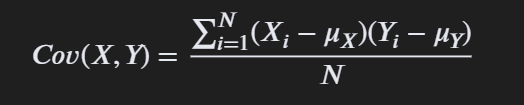

**Population Correlation**

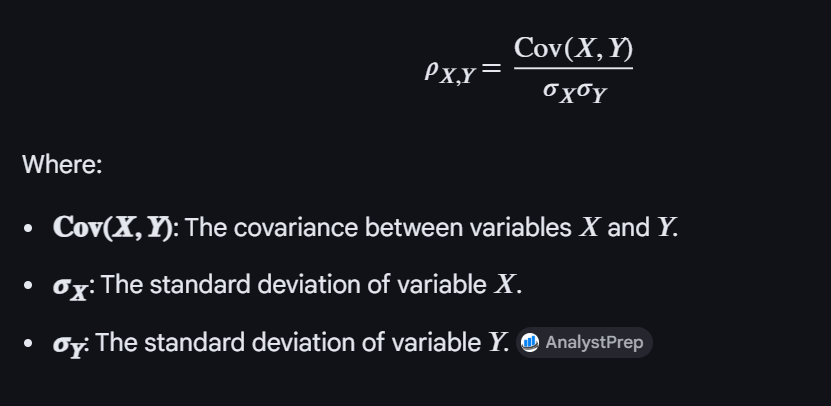

In [9]:
cor_hp_vs_wt <- cor(data$hp, data$wt)
cor_hp_vs_mpg <- cor(data$hp, data$mpg)

cat("Correlation between hp and wt:", cor_hp_vs_wt, "\n")
cat("Correlation between hp and mpg:", cor_hp_vs_mpg, "\n")

Correlation between hp and wt: 0.6587479 
Correlation between hp and mpg: -0.7761684 


In [10]:
cor_matrix <- cor(data)
cor(cor_matrix)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.0000000,-0.9907650,-0.9930998,-0.9559923,0.9393947,-0.9861081,0.7082890,0.9316708,0.8266167,0.7679063,-0.7987331
cyl,-0.9907650,1.0000000,0.9924249,0.9721722,-0.9227649,0.9662983,-0.7662891,-0.9628907,-0.7829202,-0.7352919,0.8197872
disp,-0.9930998,0.9924249,1.0000000,0.9435225,-0.9546565,0.9869528,-0.6920231,-0.9295709,-0.8428461,-0.8012728,0.7571458
hp,-0.9559923,0.9721722,0.9435225,1.0000000,-0.8188865,0.8974175,-0.8801363,-0.9848714,-0.6346633,-0.5645389,0.9243708
drat,0.9393947,-0.9227649,-0.9546565,-0.8188865,1.0000000,-0.9745412,0.4720792,0.7947272,0.9442709,0.9200555,-0.5652318
wt,-0.9861081,0.9662983,0.9869528,0.8974175,-0.9745412,1.0000000,-0.5895621,-0.8723229,-0.9025183,-0.8549249,0.6970408
qsec,0.7082890,-0.7662891,-0.6920231,-0.8801363,0.4720792,-0.5895621,1.0000000,0.8989600,0.2040082,0.1399516,-0.9488196
vs,0.9316708,-0.9628907,-0.9295709,-0.9848714,0.7947272,-0.8723229,0.8989600,1.0000000,0.5942723,0.5435689,-0.9115752
am,0.8266167,-0.7829202,-0.8428461,-0.6346633,0.9442709,-0.9025183,0.2040082,0.5942723,1.0000000,0.9787075,-0.3404780
gear,0.7679063,-0.7352919,-0.8012728,-0.5645389,0.9200555,-0.8549249,0.1399516,0.5435689,0.9787075,1.0000000,-0.2359450


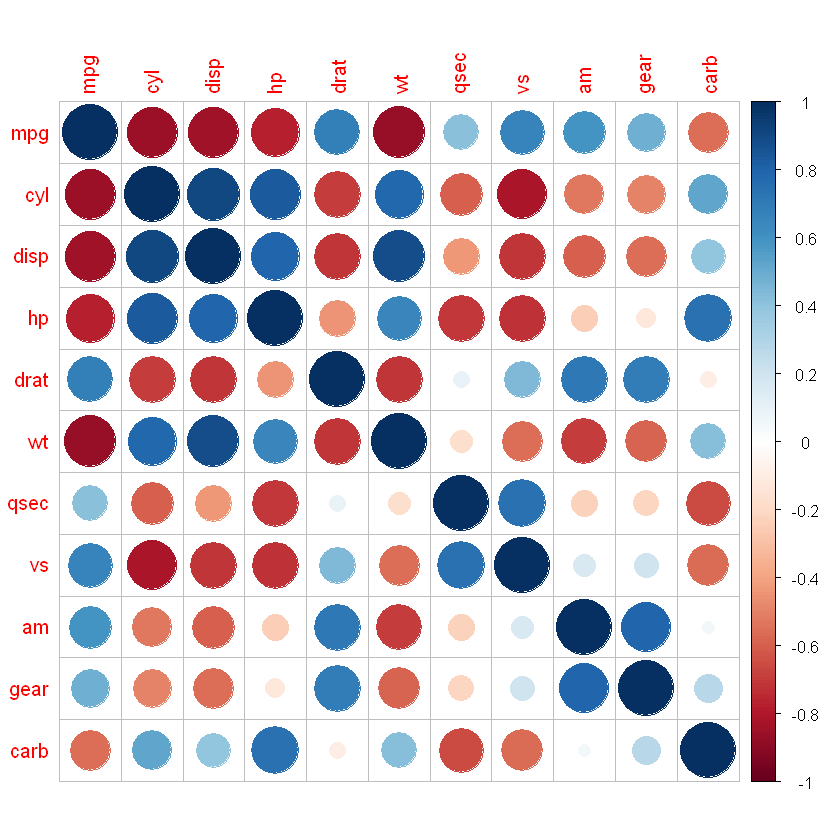

In [18]:
corrplot(cor_matrix)

- > Here dot size represents scale of correlation and color shows direction of correlation
- > Note: Diagonal is showing blue with largest dot's because correlation with same colum is always +1

### Bivariate Visualization (Numerical Vs Numerical)

In [22]:
library(ggplot2)
diamonds_data <- diamonds
head(diamonds_data)

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48


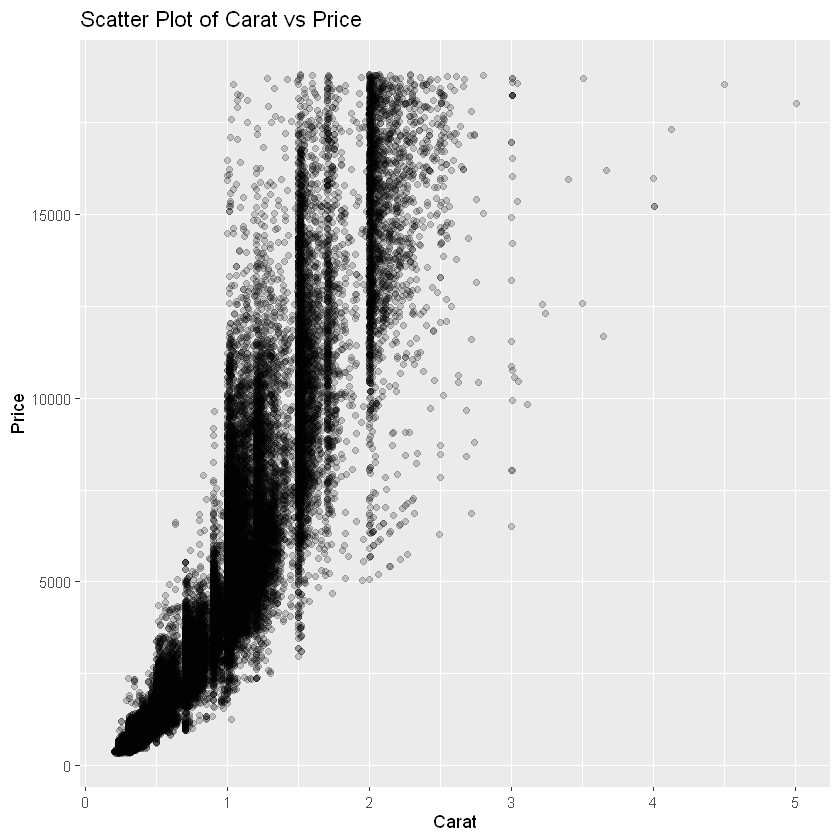

In [25]:
ggplot(diamonds_data, aes(x = carat, y = price)) + 
  geom_point(
    alpha = 0.2
  ) + 
  labs(
    title = "Scatter Plot of Carat vs Price",
    x = "Carat",
    y = "Price"
  )

Why is a scatterplot not enough? — Scatterplots are showing each datapoint with dots, so if you are dealing with huge data, you probably see a crowded graph that tells you nothing about the data, although you can adjust the transparency of the dots to see the dense area, but it is not enough if the data is very large.

> A hexagonal binning overcomes the scatterplot limitation by creating same-shape hexagons to show the correlation.

In [29]:
install.packages("hexbin", repos = "https://cloud.r-project.org")

Installing package into 'C:/Users/admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'hexbin' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\admin\AppData\Local\Temp\RtmpohkrDK\downloaded_packages


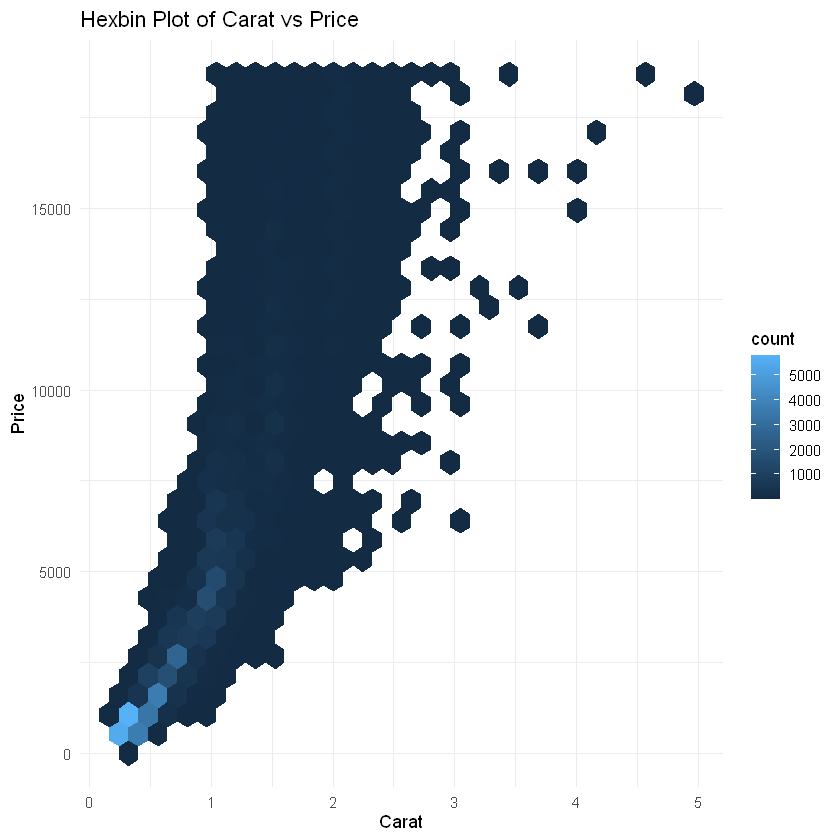

In [30]:
ggplot(diamonds_data, aes(x = carat, y = price)) + 
    geom_hex() +
    labs(
        title = "Hexbin Plot of Carat vs Price",
        x = "Carat",
        y = "Price"
    ) + 
    theme_minimal()

Why is hexagonal binning not enough? — If you see, I have plotted the same data using a scatterplot and hexagonal binning. Although hexagonal binning is able to explain the near intercept (0, 0) data, it is hugely dense but still much less informative.

> A contour plot overcomes this problem by plotting edges of dense areas, or contours of dense areas, to show more details, as you can see in the image below.

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


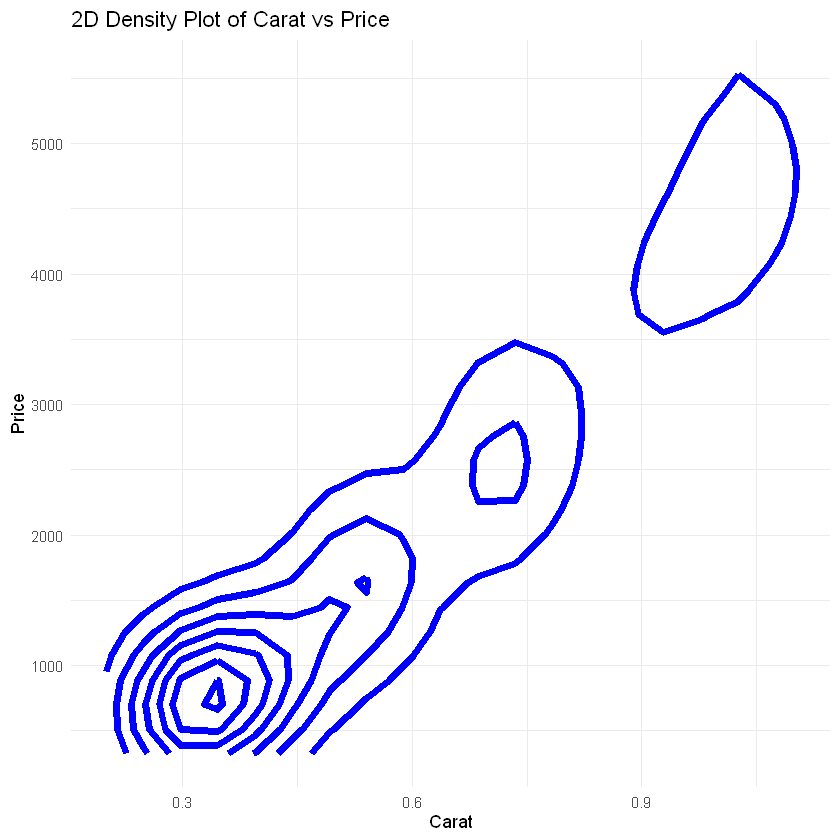

In [32]:
ggplot(diamonds_data, aes(x = carat, y = price)) + 
    geom_density_2d(
        color = "blue",
        size = 2
    ) + 
    labs(
        title = "2D Density Plot of Carat vs Price",
        x = "Carat",
        y = "Price"
    ) + 
    theme_minimal()

> So in the contour plot, you can tell that other than the intercept (0, 0), there are 2–3 denser spots.

### 2. Box plot and Violin plot (Categorical vs Numerical)
- Box Plot
- Violin Plot

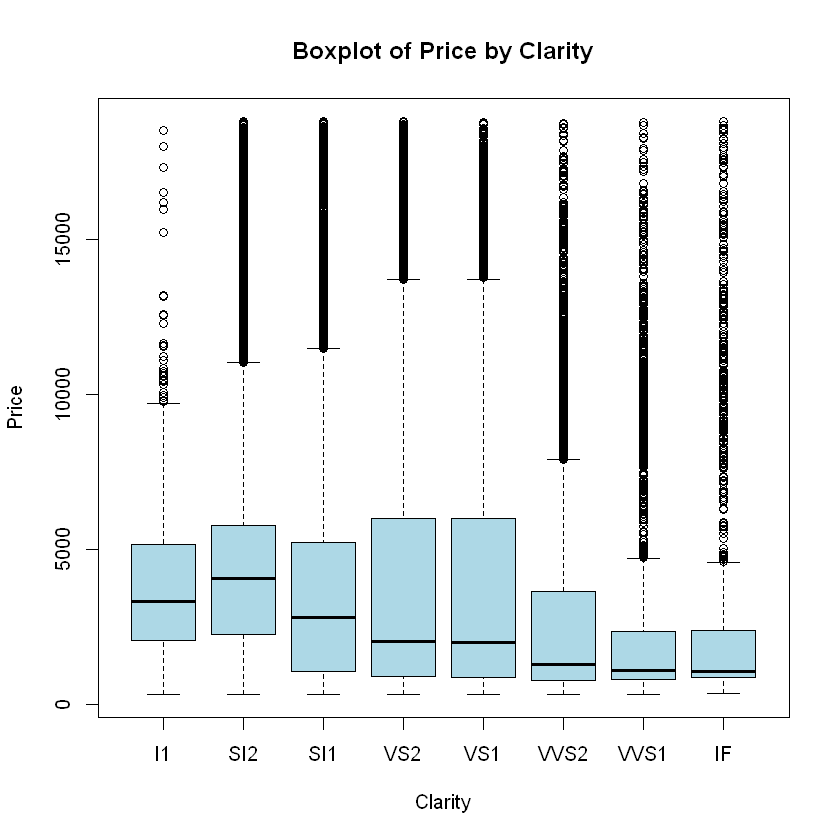

In [33]:
boxplot(price ~ clarity, data = diamonds_data, 
        main = "Boxplot of Price by Clarity", 
        xlab = "Clarity", 
        ylab = "Price", 
        col = "lightblue")

#### In summary of the box plot
1. Clarity type “IF” is the cheapest compared to others.
2. The “SI2” category holds very high pricing if you compare the 50th percentile / median.
3. “VS2” and “VS1” are very similar.
4. Long whiskers indicate that the data is more spread out and not tightly concentrated around the median.
> Why are box plots not enough? — Here box plots are not showing me the density of data with respect to price.

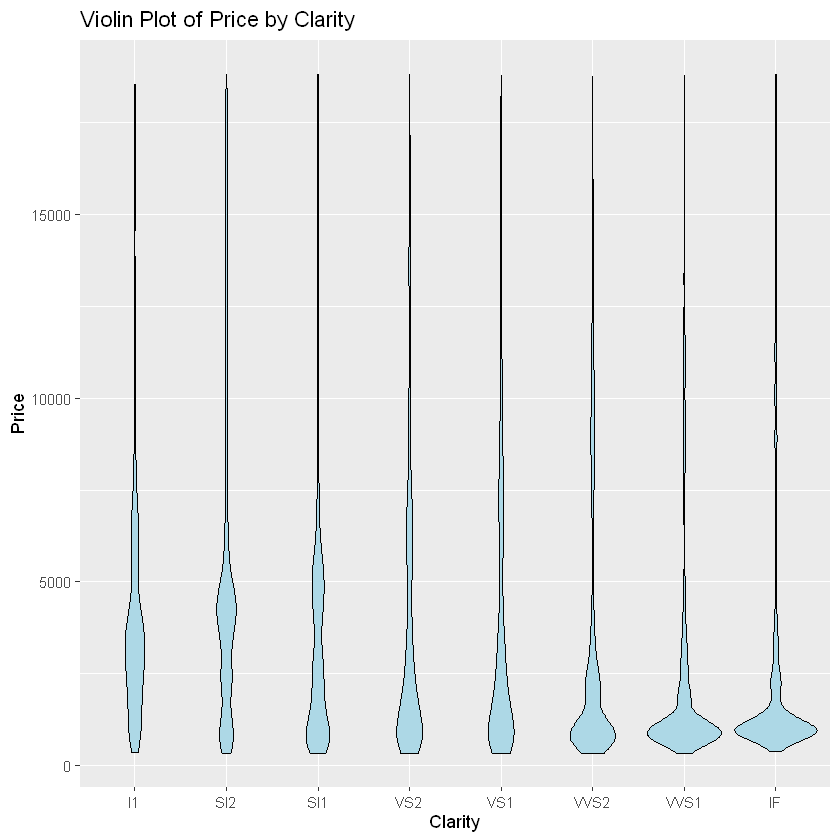

In [35]:
ggplot(diamonds_data, aes(x = clarity, y = price)) + 
    geom_violin(
        fill = "lightblue",
        color = "black"
    ) + 
    labs(
        title = "Violin Plot of Price by Clarity",
        x = "Clarity",
        y = "Price"
    )

#### In summary of the violin plot:
1. Most of the “IF” category data lies in the lower price range.
2. A large chunk of the “SI2” category is ranging around the 5000 price, so this is the most expensive category.
3. “VS2” and “VS1” are very similar.
4. If you compare the “I1” and “SI2” categories from the 5000 to 10000 price range, “I1” is higher in volume than “SI2,” which means in this range “I1” can be more expensive than “SI2.” (probability)
5. Point 4 will be very difficult to track with box plotting, but the violin plot shows that information to us very clearly.